<a href="https://colab.research.google.com/github/Lakshmi-durga-03/Smart-Parking-Management/blob/main/Smart_Parking_Management_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Parking Space Marketplace - ML Project
Complete ML Pipeline with Chi-Square Feature Selection, EDA, Models & Comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [18]:
url = 'https://raw.githubusercontent.com/Lakshmi-durga-03/Smart-Parking-Management/main/IIoT_Smart_Parking_Management.csv'

df = pd.read_csv(url)

df.head()

,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


## Dataset Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  1000 non-null   object 
 1   Parking_Spot_ID            1000 non-null   int64  
 2   Sensor_Reading_Proximity   1000 non-null   float64
 3   Sensor_Reading_Pressure    1000 non-null   float64
 4   Vehicle_Type_Weight        1000 non-null   float64
 5   Vehicle_Type_Height        1000 non-null   float64
 6   User_Type                  1000 non-null   object 
 7   Weather_Temperature        1000 non-null   float64
 8   Weather_Precipitation      1000 non-null   int64  
 9   Nearby_Traffic_Level       1000 non-null   object 
 10  Entry_Time                 1000 non-null   int64  
 11  Exit_Time                  1000 non-null   int64  
 12  Electric_Vehicle           1000 non-null   int64  
 13  Reserved_Status            1000 non-null   int64 

In [6]:
# ------------------------
# 1. Drop useless fields
# ------------------------
#df = df.drop(columns=["Timestamp"])  # Timestamp is not useful now

# ------------------------
# 2. Handle target encoding
# ------------------------
target = "Occupancy_Status"

# Convert Occupancy_Status to 0/1
df[target] = df[target].map({
    "Occupied": 1,
    "Free": 0,
    "Yes": 1,
    "No": 0
}).fillna(0).astype(int)

# ------------------------
# 3. Encode all categorical features
# ------------------------
cat_cols = df.select_dtypes(include="object").columns.tolist()
if target in cat_cols:
    cat_cols.remove(target)


le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ------------------------
# 4. Check for missing values
# ------------------------
df = df.fillna(df.median(numeric_only=True))
df = df.fillna("Unknown")

# ------------------------
# 5. Feature list ready
# ------------------------
X = df.drop(columns=[target])
y = df[target]

print("Shape:", df.shape)
print("Cleaned columns:", df.columns.tolist())
df.head()

Shape: (1000, 28)
Cleaned columns: ['Timestamp', 'Parking_Spot_ID', 'Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Vehicle_Type_Weight', 'Vehicle_Type_Height', 'User_Type', 'Weather_Temperature', 'Weather_Precipitation', 'Nearby_Traffic_Level', 'Entry_Time', 'Exit_Time', 'Electric_Vehicle', 'Reserved_Status', 'Occupancy_Rate', 'Payment_Amount', 'Parking_Lot_Section', 'Payment_Status', 'Occupancy_Status', 'Vehicle_Type', 'Parking_Violation', 'Sensor_Reading_Ultrasonic', 'Parking_Duration', 'Environmental_Noise_Level', 'Dynamic_Pricing_Factor', 'Spot_Size', 'Proximity_To_Exit', 'User_Parking_History']


,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,0,20,1.023651,1.541461,1831.770127,4.392528,2,18.092553,1,1,...,1,0,0,102.951052,4,55.620740,0.8,2,6.610474,6.660310
1,1,49,3.903349,1.621719,1330.815754,4.595638,0,13.397533,0,1,...,1,0,0,87.559131,3,56.682386,1.2,0,8.678719,6.766187
2,2,38,10.315709,6.292374,1255.134827,4.313721,0,21.687410,0,0,...,0,0,1,100.061854,5,59.239322,0.8,2,13.795262,-0.910052
3,3,31,6.588039,1.659870,1523.442919,3.567329,2,18.683461,0,2,...,0,2,1,110.594598,2,44.545155,0.8,2,1.678721,10.415888
4,4,8,8.213969,3.278467,1758.490837,5.145836,2,19.214876,0,0,...,1,0,0,84.786963,2,48.012604,0.8,2,20.012252,4.355544


## EDA - Countplot of Target

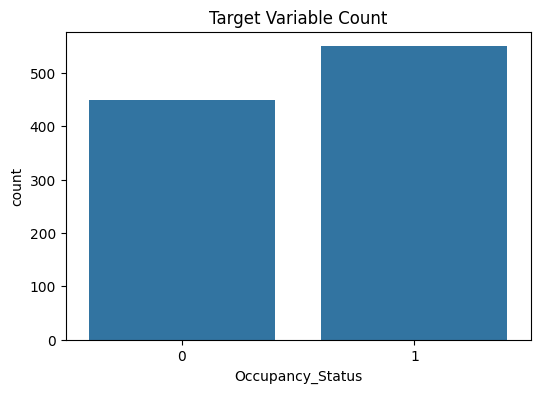

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Occupancy_Status'])
plt.title("Target Variable Count")
plt.show()

## Correlation Heatmap

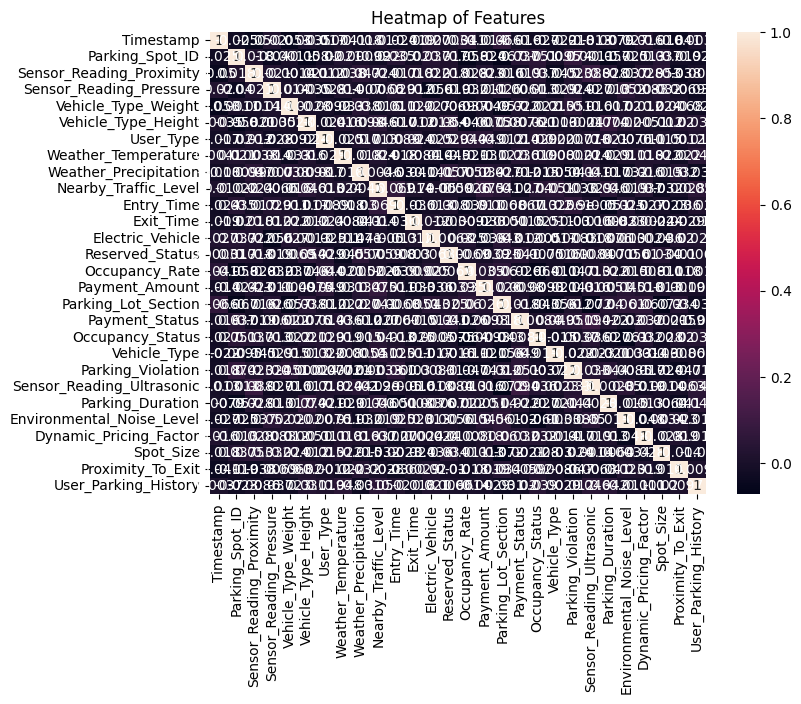

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Heatmap of Features")
plt.show()

## Encode Categorical Columns

In [9]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,1970-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,2,18.092553,1,1,...,1,0,0,102.951052,4,55.620740,0.8,2,6.610474,6.660310
1,1970-01-01 00:00:00.000000001,49,3.903349,1.621719,1330.815754,4.595638,0,13.397533,0,1,...,1,0,0,87.559131,3,56.682386,1.2,0,8.678719,6.766187
2,1970-01-01 00:00:00.000000002,38,10.315709,6.292374,1255.134827,4.313721,0,21.687410,0,0,...,0,0,1,100.061854,5,59.239322,0.8,2,13.795262,-0.910052
3,1970-01-01 00:00:00.000000003,31,6.588039,1.659870,1523.442919,3.567329,2,18.683461,0,2,...,0,2,1,110.594598,2,44.545155,0.8,2,1.678721,10.415888
4,1970-01-01 00:00:00.000000004,8,8.213969,3.278467,1758.490837,5.145836,2,19.214876,0,0,...,1,0,0,84.786963,2,48.012604,0.8,2,20.012252,4.355544


In [10]:
# Force convert everything to numeric where possible
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Replace NaN from coercion
X = X.fillna(0)


In [11]:
y = df['Occupancy_Status']
X = df.drop('Occupancy_Status', axis=1)

# FORCE numeric conversion (REAL FIX)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Replace NaNs
X = X.fillna(0)

# Scale
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


## Chi-Square Feature Selection

In [12]:
selector = SelectKBest(score_func=chi2, k=10)
chi_selector = selector.fit(X_scaled, y)

chi_scores = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Chi2 Score': chi_selector.scores_
}).sort_values(by='Chi2 Score', ascending=False)

chi_scores

,Feature,Chi2 Score
6,User_Type,0.612577
16,Parking_Lot_Section,0.605250
14,Occupancy_Rate,0.487599
1,Parking_Spot_ID,0.486288
23,Dynamic_Pricing_Factor,0.364799
9,Nearby_Traffic_Level,0.238004
8,Weather_Precipitation,0.215311
2,Sensor_Reading_Proximity,0.198029
22,Environmental_Noise_Level,0.177757
24,Spot_Size,0.161118


## Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train/Test Split Done.")

Train/Test Split Done.


## Train Models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

accuracies = {}

# Store predictions separately
y_pred_log = None
y_pred_dt = None
y_pred_rf = None

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, preds)

    if name == "Logistic Regression":
        y_pred_log = preds
    elif name == "Decision Tree":
        y_pred_dt = preds
    elif name == "Random Forest":
        y_pred_rf = preds

accuracies


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.485, 'Decision Tree': 0.515, 'Random Forest': 0.535}

## Accuracy Comparison Graph

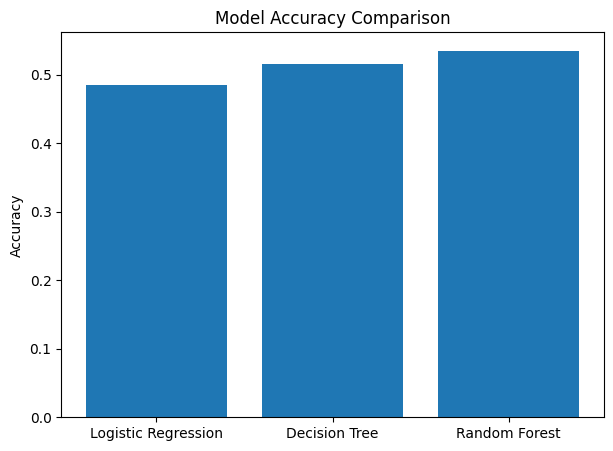

In [15]:
plt.figure(figsize=(7,5))
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

# Decision Tree
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Random Forest
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)


models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

performance_summary = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Precision': [precision_log, precision_dt, precision_rf],
    'Recall': [recall_log, recall_dt, recall_rf],
    'F1-Score': [f1_log, f1_dt, f1_rf]
})

print("\n=== Model Performance Summary ===")
print(performance_summary.round(4))


most_efficient_model = performance_summary.loc[performance_summary['Accuracy'].idxmax()]

print(f"\nMost Efficient Model (based on Accuracy):\n"
      f"{most_efficient_model['Model']} with Accuracy: {most_efficient_model['Accuracy']:.4f}")



=== Model Performance Summary ===
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.485     0.5000  0.7184    0.5896
1        Decision Tree     0.515     0.5283  0.5437    0.5359
2        Random Forest     0.535     0.5338  0.7670    0.6295

Most Efficient Model (based on Accuracy):
Random Forest with Accuracy: 0.5350
